In [1]:
import numpy as np
import pandas as pd
import xarray as xr

import dask.distributed
from pystac_client import Client
import stackstac
import geopandas as gpd
import rioxarray as xrx

import planetary_computer

from pystac.extensions.eo import EOExtension as eo
import odc.stac
import cv2 as cv

import matplotlib.pyplot as plt
from rasterio.plot import reshape_as_image, reshape_as_raster
from tqdm import tqdm
import os, glob

In [2]:
os.chdir('/home/s.behzad.valipour/magenta/Data')

In [4]:
gdf = gpd.read_file("./Raw_Data/Wales_Grid_20km.gpkg")

In [5]:
catalog = Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

In [6]:
time_of_interest = "2010-01-01/2023-12-31"

In [7]:
def NDVI(data):
    red = data["red"].astype("float")
    nir = data["nir08"].astype("float")
    ndvi = (nir - red) / (nir + red)
    return ndvi

In [8]:
def MASK(data):
    # Make a bitmask---when we bitwise-and it with the data, it leaves just the 4 bits we care about
    mask_bitfields = [1, 2, 3, 4]  # dilated cloud, cirrus, cloud, cloud shadow
    bitmask = 0
    for field in mask_bitfields:
        bitmask |= 1 << field

    qa = data["qa_pixel"].astype("uint16")
    bad = qa & bitmask  # just look at those 4 bits
    good = data.where(bad == 0) 
    return good

In [9]:
def temperature(data):
    temp = data["lwir11"].astype(float)
    temp *= 0.003418020
    temp += 149.0
    temp = temp.where(temp != 149, np.nan)
    return temp

In [10]:
def to_df(data,name):
    data.name = name
    df = data.to_dataframe().reset_index().drop(columns=['spatial_ref'])
    df["BID"] = (np.floor(df["y"] / 1000) * 100000 + 
                          np.floor(df["x"] / 1000)).convert_dtypes()

    return df

In [32]:
def inpainting(data):
    """
    Fills in missing values in the input data using inpainting techniques.
    
    Parameters:
    data (numpy.ndarray): Input array with potential NaN values.

    Returns:
    numpy.ndarray: Array with NaN values filled using inpainting, 
                   or the original array if no NaNs are present.
    """
    # Mask for NaN values
    data_copy = np.copy(data)
    na_data_mask = np.isnan(data_copy)

    # If no NaN values, return data as is
    if not na_data_mask.any():
        return data

    # Replace NaNs with the initial median value
    initial_value = np.nanmedian(data_copy)
    data_copy = data_copy.astype('float32')
    data_copy[na_data_mask] = initial_value

    # Inpainting to fill missing data
    filled_data = cv.inpaint(data_copy, na_data_mask.astype('uint8'), 10, cv.INPAINT_NS)
    return filled_data


In [33]:
def gapfill_data(data):
    """
    Applies inpainting to fill gaps in each band of the input data array.

    Parameters:
    data (numpy.ndarray): 3D array where each slice along the first axis is a band.

    Returns:
    numpy.ndarray: Array with gap-filled bands.
    """
    data_copy = data.copy(deep=True)
    num_bands = data_copy.shape[0]

    # Gap-filling each specified band
    gapfilled_bands = []
    for idx in range(num_bands):
        band = data_copy[idx, ...]
        band_gapfilled = inpainting(band)
        gapfilled_bands.append(band_gapfilled)

    # Stack processed bands
    gapfilled_array = np.stack(gapfilled_bands, axis=0)
    
    # Update data with gap-filled bands
    data_copy.values = gapfilled_array
    return data_copy


In [13]:
df_lst=[]
for idx, row in tqdm(gdf.bounds.iterrows()):
    # bbox_of_interest = row.to_list()
    bbox_of_interest = [-3.765393,52.225102,-3.465562, 52.408847]
    search = catalog.search(
        collections=["landsat-c2-l2"],
        bbox=bbox_of_interest,
        datetime=time_of_interest,
        query={
            "eo:cloud_cover": {"lt":20 },
            "platform": {"in": ["landsat-8"]}  # Use a valid dictionary format
        },
     )


    items = search.item_collection()

    bands_of_interest = ["red", "nir08","lwir11", "qa_pixel"]
    # bands_of_interest = ["red", "green","blue", "qa_pixel"]
    data = odc.stac.stac_load(
        items, bands=bands_of_interest, 
        bbox=bbox_of_interest,
        resolution=30,
        crs=27700
    )

    data_mask = MASK(data)
    ndvi = NDVI(data_mask).groupby("time.season").median(dim="time")
    lst = temperature(data_mask).groupby("time.season").median(dim="time")

    gapfilled_ndvi = gapfill_data(ndvi)
    gapfilled_lst = gapfill_data(lst)

    df_ndvi_seasons = to_df(gapfilled_ndvi,'ndvi')
    df_lst_seasons = to_df(gapfilled_lst,'lst_landsat')

    df = pd.merge(df_ndvi_seasons,df_lst_seasons,on=['BID','season','x','y'])
    df_lst.append(df)


df_lst_ndvi=pd.concat(df_lst)

df_lst_ndvi.to_parquet(f'./Processed_Data/ndvi_landsat_Wales/NDVI_LST_Landsat8_Seasonal.parquet')

0it [01:42, ?it/s]


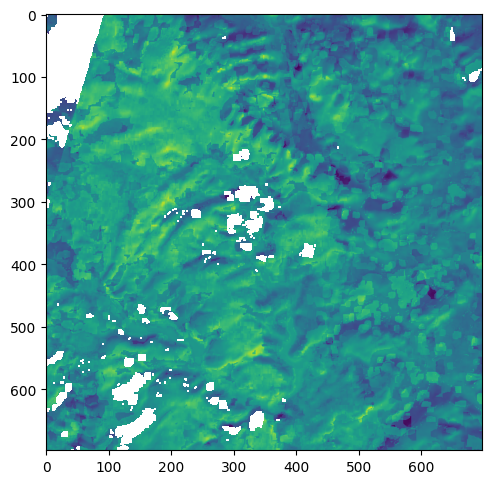

In [18]:
num_bands = ndvi.shape[0]
fig, axes = plt.subplots(1, 1, figsize=(5, 5))
seasons = ['Winter', 'Summer' ,'Spring', 'Fall']
plt.imshow(lst.values[0, ...], cmap='viridis')

plt.tight_layout()
plt.show()

In [35]:
from scipy import ndimage

In [36]:
def conv_mapping(x):
    """
    When the fifth value (x[4]) of the filter array (the center of the window) 
    is null, replace it with the mean of the surrounding values.
    """
    if np.isnan(x[60]) and not np.isnan(np.delete(x, 60)).all():
        return np.nanmean(np.delete(x, 60))
    else:
        return x[60]

In [37]:
grid_smooth = ndimage.generic_filter(lst.values[0, ...],
            function=conv_mapping,
            footprint=np.ones((11,11)), mode='constant', cval=np.nan)

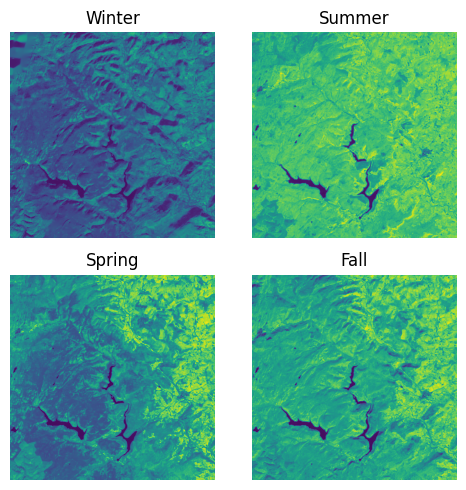

In [38]:
num_bands = ndvi.shape[0]
fig, axes = plt.subplots(2, 2, figsize=(5, 5))
seasons = ['Winter', 'Summer' ,'Spring', 'Fall']
for i in range(num_bands):
    ax = axes[i // 2, i % 2]  # 2x2 grid layout
    ax.imshow(gapfilled_ndvi.values[i, ...], cmap='viridis')
    ax.set_title(f'{seasons[i]}')
    ax.axis('off')

plt.tight_layout()
plt.show()

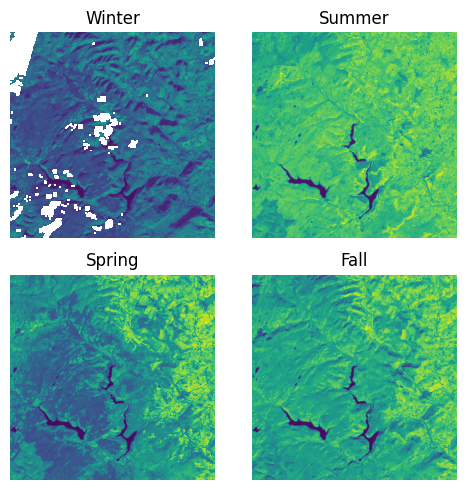

In [39]:
num_bands = ndvi.shape[0]
fig, axes = plt.subplots(2, 2, figsize=(5, 5))
seasons = ['Winter', 'Summer' ,'Spring', 'Fall']
for i in range(num_bands):
    ax = axes[i // 2, i % 2]  # 2x2 grid layout
    ax.imshow(ndvi[i, ...], cmap='viridis')
    ax.set_title(f'{seasons[i]}')
    ax.axis('off')

plt.tight_layout()
plt.show()